corn ../data/corn/s2/s2_y2018_p2751_full.tif


/tmp/ipykernel_4139844/1933159067.py:65: RuntimeWarning: invalid value encountered in subtract
  (nir - red) /
/tmp/ipykernel_4139844/1933159067.py:77: RuntimeWarning: Mean of empty slice
  np.nanmean(month_ndvi)


barley ../data/barley/s2/s2_y2018_p36964_full.tif
wheat ../data/wheat/s2/s2_y2018_p44905_full.tif
rice ../data/rice/s2/s2_y2019_p0030_full.tif
kolza ../data/kolza/s2/s2_y2018_p0041_full.tif


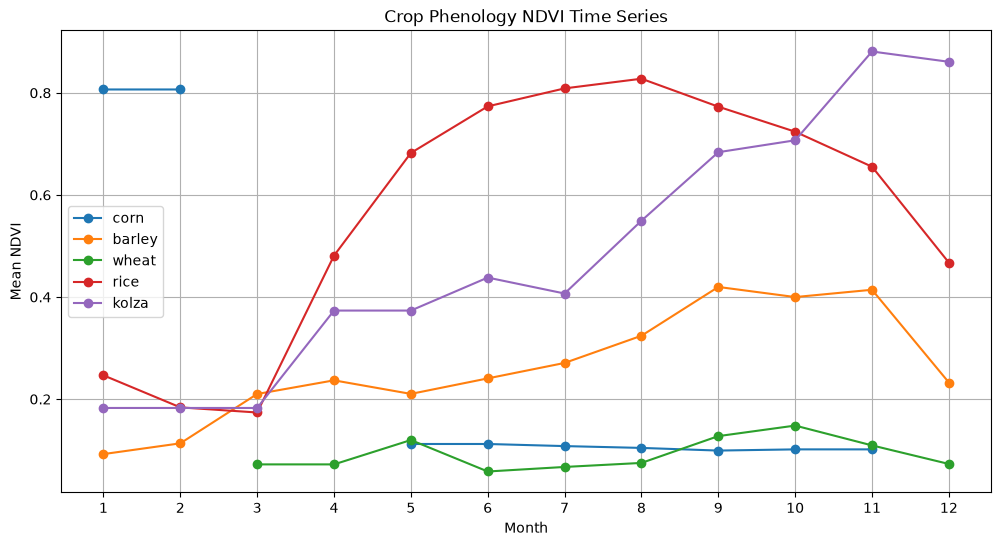

In [11]:
import os
import glob
import random
import rasterio
import numpy as np
import matplotlib.pyplot as plt


DATA_DIR = "../data"

crops = [
    "corn",
    "barley",
    "wheat",
    "rice",
    "kolza"
]


def find_random_tif(crop):
    files = glob.glob(
        os.path.join(DATA_DIR, crop, "s2", "*.tif")
    )

    if len(files) == 0:
        raise RuntimeError(f"No files found for {crop}")

    return random.choice(files)



def read_s2_timeseries(path):

    with rasterio.open(path) as src:
        data = src.read()
        descriptions = src.descriptions

    return data, descriptions



def extract_ndvi_timeseries(data, descriptions):
    """
    data shape:
        (121, H, W)

    returns:
        12 monthly NDVI values
    """

    ndvi = []

    # first 120 bands = 12 months * 10 bands
    for month in range(12):

        start = month * 10

        # Sentinel-2 order:
        # B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12

        red = data[start + 2].astype(float)  # B4
        nir = data[start + 6].astype(float)  # B8

        month_ndvi = (
            (nir - red) /
            (nir + red + 1e-6)
        )

        # remove invalid pixels
        month_ndvi = np.where(
            np.isfinite(month_ndvi),
            month_ndvi,
            np.nan
        )

        ndvi.append(
            np.nanmean(month_ndvi)
        )

    return np.array(ndvi)



results = {}


for crop in crops:

    tif = find_random_tif(crop)

    print(crop, tif)

    data, descriptions = read_s2_timeseries(tif)

    ts = extract_ndvi_timeseries(
        data,
        descriptions
    )

    results[crop] = ts



# --------------------------
# Plot
# --------------------------

months = np.arange(1,13)


plt.figure(figsize=(12,6))


for crop, ts in results.items():

    plt.plot(
        months,
        ts,
        marker="o",
        label=crop
    )


plt.xlabel("Month")
plt.ylabel("Mean NDVI")
plt.title("Crop Phenology NDVI Time Series")
plt.xticks(months)
plt.grid()
plt.legend()

plt.show()

In [ ]:
import os
import glob
import random
import rasterio


DATA_DIR = "../data"

crops = [
    "corn",
    "barley",
    "wheat",
    "rice",
    "kolza"
]


def find_random_tif(crop):
    files = glob.glob(
        os.path.join(DATA_DIR, crop, "s2", "*.tif")
    )
    if not files:
        raise FileNotFoundError(f"No tif found for {crop}")
    return random.choice(files)


for crop in crops:

    tif = find_random_tif(crop)

    print("=" * 80)
    print("Crop:", crop)
    print("File:", tif)

    with rasterio.open(tif) as src:
        print("Shape:")
        print("  Bands:", src.count)
        print("  Height:", src.height)
        print("  Width:", src.width)

        print("\nDtype:")
        print(src.dtypes)

        print("\nCRS:")
        print(src.crs)

        print("\nTransform:")
        print(src.transform)

        print("\nBand descriptions:")
        print(src.descriptions)

        print("\nTags:")
        print(src.tags())

        print("\nBand statistics:")
        for i in range(1, src.count + 1):
            band = src.read(i, masked=True)
            print(
                f"Band {i}: "
                f"min={band.min():.4f}, "
                f"max={band.max():.4f}, "
                f"mean={band.mean():.4f}"
            )

    print()

Crop: corn
File: ../data/corn/s2/s2_y2018_p1890_full.tif
Shape:
  Bands: 121
  Height: 59
  Width: 64

Dtype:
('float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32'

/tmp/ipykernel_4139844/1835218102.py:61: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  f"min={band.min():.4f}, "
/tmp/ipykernel_4139844/1835218102.py:62: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  f"max={band.max():.4f}, "
/tmp/ipykernel_4139844/1835218102.py:63: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  f"mean={band.mean():.4f}"


Band 59: min=1726.0000, max=4508.0000, mean=3340.2836
Band 60: min=1340.0000, max=4336.0000, mean=2882.6927
Band 61: min=321.7500, max=3199.5000, mean=1024.2924
Band 62: min=802.7500, max=3180.0000, mean=1474.4567
Band 63: min=524.7500, max=3726.0000, mean=1981.7720
Band 64: min=1177.5000, max=3443.5000, mean=2229.6010
Band 65: min=1507.7500, max=3759.0000, mean=2350.6803
Band 66: min=1626.5000, max=3884.5000, mean=2491.6726
Band 67: min=1642.5000, max=4548.5000, mean=2584.6890
Band 68: min=1737.7500, max=3979.0000, mean=2639.7109
Band 69: min=2321.7500, max=4579.5000, mean=3400.2793
Band 70: min=1553.7500, max=4395.2500, mean=2987.2166
Band 71: min=497.0000, max=3187.0000, mean=1147.9004
Band 72: min=877.5000, max=3128.0000, mean=1590.5308
Band 73: min=693.0000, max=3744.0000, mean=2074.9793
Band 74: min=1299.0000, max=3372.0000, mean=2321.4991
Band 75: min=1777.5000, max=3705.0000, mean=2465.1895
Band 76: min=1873.5000, max=3745.0000, mean=2601.7462
Band 77: min=1906.0000, max=4324.0

: 